<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%A0%D0%B5%D1%88%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D1%87%D0%B8_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D0%B8_%D1%81_%D0%BF%D0%BE%D0%BC%D0%BE%D1%89%D1%8C%D1%8E_%D0%BD%D0%B5%D0%B9%D1%80%D0%BE%D0%BD%D0%BD%D1%8B%D1%85_%D1%81%D0%B5%D1%82%D0%B5%D0%B9_%7C_%D0%94%D0%97_Ultra_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

По базе машин с ЮЛЫ данным обучите модель для предсказания цен на машины.

1. Создайте обучающую, тестовую и проверочную выборки.

2. Оцените качество работы созданной сети, определив средний процент ошибки на проверочной выборке. (Для этого потребуется привести предсказанные моделью значения к первоначальному диапазону цен.)  

3. Подсчитайте ошибку на каждом примере тестовой выборки и суммарный процент ошибки.


Рекомендации:
- в качестве ошибки рекомендуется использовать среднеквадратическую ошибку (mse).
- метрику для данной задачи можно не использовать.
- последний слой модели должен иметь 1 нейрон.
- суммарный процент ошибки = средний модуль ошибки (MAE) / среднюю цену машины. Например, если средняя цена машины 560.000 р, а средняя ошибка 56.000р, то процент ошибки равен 10%.


In [1]:
# Загрузка датафрейма из google облака
import gdown

gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l10/cars_new.csv', None, quiet=True)

'cars_new.csv'

In [2]:
# Ваше решение
import numpy as np
import pandas as pd
# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential, Model

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation, Input, concatenate
from tensorflow.keras.layers import SimpleRNN, GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

# Оптимизаторы
from tensorflow.keras.optimizers import Adam, Adadelta, SGD, Adagrad, RMSprop

# Токенизатор для преобразование текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Масштабирование данных
from sklearn.preprocessing import StandardScaler

# Загрузка датасетов из облака google
import gdown

# Регулярные выражения
import re

# Отрисовка графиков
import matplotlib.pyplot as plt

# Метрики для расчета ошибок
from sklearn.metrics import mean_squared_error, mean_absolute_error

%matplotlib inline


In [3]:
df = pd.read_csv('cars_new.csv')
display(df.head())
display(df.info())
print(df.shape)
display(df.isna().sum())

,mark,model,price,year,mileage,body,kpp,fuel,volume,power
0,kia,cerato,996000,2018,28000,седан,автомат,бензин,2.0,150.0
1,daewoo,nexia 1 поколение [2-й рестайлинг],140200,2012,60500,седан,механика,бензин,1.5,80.0
2,suzuki,jimny 3 поколение [рестайлинг],750000,2011,29000,внедорожник,автомат,бензин,1.3,85.0
3,bmw,x1 18 e84 [рестайлинг],970000,2014,49500,кроссовер,автомат,бензин,2.0,150.0
4,chevrolet,lacetti 1 поколение,205000,2007,151445,седан,механика,бензин,1.4,95.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70119 entries, 0 to 70118
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   mark     70119 non-null  object 
 1   model    70119 non-null  object 
 2   price    70119 non-null  int64  
 3   year     70119 non-null  int64  
 4   mileage  70119 non-null  int64  
 5   body     70116 non-null  object 
 6   kpp      70115 non-null  object 
 7   fuel     70119 non-null  object 
 8   volume   70119 non-null  float64
 9   power    70119 non-null  float64
dtypes: float64(2), int64(3), object(5)
memory usage: 5.3+ MB


None

(70119, 10)


,0
mark,0
model,0
price,0
year,0
mileage,0
body,3
kpp,4
fuel,0
volume,0
power,0


In [4]:
print(df.mark.unique(), len(df.mark.unique()))
print(df.model.unique(), len(df.model.unique()))
print(df.body.unique(), len(df.body.unique()))
print(df.fuel.unique(), len(df.fuel.unique()))

['kia' 'daewoo' 'suzuki' 'bmw' 'chevrolet' 'hyundai' 'toyota'
 'mercedes-benz' 'chery' 'ford' 'mazda' 'peugeot' 'volkswagen' 'audi'
 'mitsubishi' 'opel' 'nissan' 'skoda' 'subaru' 'honda' 'renault'] 21
['cerato' 'nexia 1 поколение [2-й рестайлинг]'
 'jimny 3 поколение [рестайлинг]' ... 'model f'
 'clk-класс 200 w208/a208 [рестайлинг]' 'x3 f25'] 3156
['седан' 'внедорожник' 'кроссовер' 'хетчбэк' 'универсал' 'минивэн'
 'лифтбэк' 'купе' 'микроавтобус' 'пикап' 'кабриолет' 'хардтоп' 'родстер'
 'тарга' nan 'лимузин' 'фастбэк'] 17
['бензин' 'дизель' 'гибрид' 'электро' 'газ'] 5


In [5]:
y_train = np.array(df['price'].astype('int'))
data_model = df['model'].values #
print(len(data_model)) #

70119


In [6]:
# Импортируем токенайзер
from tensorflow.keras.preprocessing.text import Tokenizer

maxWordsCount = 5000
sim_for_del='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
tokenizer = Tokenizer (num_words=maxWordsCount,
                       filters=sim_for_del,
                       lower=True,
                       split=' ',
                       oov_token='unknown',
                       char_level=False)
tokenizer.fit_on_texts(data_model)
# Переводим в Эмбеддинг пространство
Sequences = tokenizer.texts_to_sequences(data_model)
# Вариант  Bag of Words
xBOW_model = tokenizer.sequences_to_matrix(Sequences)
print(Sequences[0:10])
print(xBOW_model.shape, xBOW_model[0:10])
df.head()

[[115], [12, 4, 2, 5, 13, 3], [345, 6, 2, 3], [201, 378, 233, 3], [43, 4, 2], [260, 4, 2], [59, 5, 2], [44, 290], [27, 7, 95, 172, 173, 304, 3], [25, 9, 525, 369, 370]]
(70119, 5000) [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


,mark,model,price,year,mileage,body,kpp,fuel,volume,power
0,kia,cerato,996000,2018,28000,седан,автомат,бензин,2.0,150.0
1,daewoo,nexia 1 поколение [2-й рестайлинг],140200,2012,60500,седан,механика,бензин,1.5,80.0
2,suzuki,jimny 3 поколение [рестайлинг],750000,2011,29000,внедорожник,автомат,бензин,1.3,85.0
3,bmw,x1 18 e84 [рестайлинг],970000,2014,49500,кроссовер,автомат,бензин,2.0,150.0
4,chevrolet,lacetti 1 поколение,205000,2007,151445,седан,механика,бензин,1.4,95.0


In [7]:
marks = df.mark.unique()
bodies = df.body.unique()
fuels = df.fuel.unique()
kpps = df.kpp.unique()

COL_MARK     = df.columns.get_loc('mark')
COL_MODEL      = df.columns.get_loc('model')
COL_PRICE    = df.columns.get_loc('price')
COL_YEAR    = df.columns.get_loc('year')
COL_MILEAGE        = df.columns.get_loc('mileage')
COL_BODY        = df.columns.get_loc('body')
COL_KPP       = df.columns.get_loc('kpp')
COL_FUEL         = df.columns.get_loc('fuel')
COL_VOLUME         = df.columns.get_loc('volume')
COL_POWER     = df.columns.get_loc('power')


 # Получение one hot encoding представления значения класса
def val_to_ohe(arg, class_list):
    # Определение размерности выходного вектора
    num_classes = len(class_list)
    # Поиск верного интервала для входного значения
    for i in range(num_classes - 1):
        if arg == class_list[i]:
            cls = i
            break
    else:
        cls = num_classes - 1
    # Возврат в виде one hot encoding-вектора
    return utils.to_categorical(cls, num_classes)

def extract_row_data(row):
    mark_vec = val_to_ohe(row[COL_MARK], marks)
    age = np.array([2025 - row[COL_YEAR]])
    mileage = np.array([row[COL_MILEAGE]])
    body_vec = val_to_ohe(row[COL_BODY], bodies)
    kpp_vec = val_to_ohe(row[COL_KPP], kpps)
    fuel_vec = val_to_ohe(row[COL_FUEL], fuels)
    volume = np.array([row[COL_VOLUME]])
    power = np.array([row[COL_POWER]])

    # Объединение всех входных данных в один общий вектор
    x_data = np.hstack([
                        mark_vec,
                        age,
                        mileage,
                        body_vec,
                        kpp_vec,
                        fuel_vec,
                        volume,
                        power
    ])

    # Возврат входных данных и выходных (зарплаты)
    return x_data, int(row[COL_PRICE])


# Создание общей выборки
def construct_train_data(row_list):
    x_data = []
    y_data = []

    for row in row_list:
        x, y = extract_row_data(row)
        if y > 0:                      # Данные добавляются, только если есть цена
            x_data.append(x)
            y_data.append(y)

    return np.array(x_data), np.array(y_data)

In [8]:
# Формирование выборки из загруженного набора данных
x_train_01, y_train = construct_train_data(df.values)
print(x_train_01.shape, y_train.shape)

(70119, 52) (70119,)


In [9]:
print(x_train_01[0:10])

[[1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 7.00000e+00 2.80000e+04 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 2.00000e+00 1.50000e+02]
 [0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 1.30000e+01 6.05000e+04 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00

In [10]:
def plot_history(history):
    plt.plot(history.history['mae'],
            label='Средняя абсолютная на обучающем наборе')
    plt.plot(history.history['val_mae'],
            label='Средняя абсолютная  ошибка на проверочном наборе')
    plt.xlabel('Эпоха обучения')
    plt.ylabel('Средняя абсолютная  ошибка')
    plt.legend()
    plt.show()

# Функция оценки результатов и вывода оценки

def eval_net(model, x_train, y_train, y_scaler = None, n = 10, limit = 10000000.):
    pred = model.predict(x_train)             # Предсказание на тренировочной выборке
    if y_scaler:                              # Если есть нормирование - то денормировать
        pred = y_scaler.inverse_transform(pred)

    print('Средняя абсолютная ошибка:', mean_absolute_error(pred, y_train), '\n')

    for i in range(n):
        print('Реальное значение: {:6.2f}  Предсказанное значение: {:6.2f}  Разница: {:6.2f}'.format(y_train[i, 0],
                                                                                                    pred[i, 0],
                                                                                                    abs(y_train[i, 0] - pred[i, 0])))
    # Построение картинки разброса предсказанных и верных значений зарплаты
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_train, pred)                 # Отрисовка точечного графика
    ax.set_xlim(0, limit)                     # Пределы по x, y
    ax.set_ylim(0, limit)
    ax.plot(plt.xlim(), plt.ylim(), 'r')      # Отрисовка диагональной линии
    plt.xlabel('Правильные значения')
    plt.ylabel('Предсказания')
    plt.grid()
    plt.show()

In [11]:
# Для нормализации данных используется готовый инструмент
y_scaler = StandardScaler()

# Нормализация выходных данных по стандартному нормальному распределению
y_train_exp = np.expand_dims(y_train, axis=1)
y_train_scaled = y_scaler.fit_transform(y_train_exp)
y_train_reversed = y_scaler.inverse_transform(y_train_scaled)
# Проверка нормализации
print(y_train_scaled.shape)
print(f'Оригинальное значение цены:  {y_train_exp[1, 0]}')
print(f'Нормированное значение цены: {y_train_scaled[1, 0]}')
print(f'Денормированное значение цены: {y_train_reversed[1, 0]}')

# Вывод границ ненормализованных и нормализованных данных
print(y_train.mean(), y_train.std())
print(y_train_scaled.mean(), y_train_scaled.std())

(70119, 1)
Оригинальное значение цены:  140200
Нормированное значение цены: -0.6213543442670795
Денормированное значение цены: 140200.0
527726.1014275731 623679.7167398593
-8.714710032283492e-18 1.0000000000000002


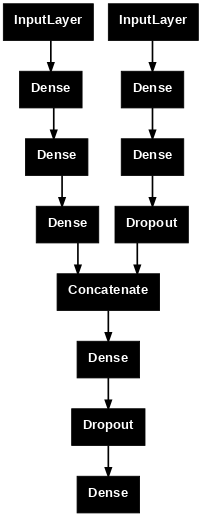

In [12]:
input1 = Input((x_train_01.shape[1],))
input2 = Input((xBOW_model.shape[1],))

x1 = input1                               # Ветка 1
x1 = Dense(128, activation="relu")(x1)
x1 = Dense(1000, activation="relu")(x1)
x1 = Dense(100, activation="relu")(x1)

x2 = input2                               # Ветка 2
x2 = Dense(20, activation="relu")(x2)
x2 = Dense(500, activation="relu")(x2)
x2 = Dropout(0.3)(x2)


x = concatenate([x1, x2])             # Объединение трех веток

x = Dense(15, activation='relu')(x)       # Промежуточный слой
x = Dropout(0.5)(x)
x = Dense(1, activation='linear')(x)      # Финальный регрессирующий нейрон

# В Model передаются входы и выход

model_final = Model((input1, input2), x)
display(utils.plot_model(model_final, dpi=60))
model_final.compile(optimizer=Adam(learning_rate=1e-4), loss='mse', metrics=['mae'])

In [13]:
history = model_final.fit([x_train_01, xBOW_model],
                           y_train_scaled,
                           batch_size=256,
                           epochs=50,
                           validation_split=0.2,
                           verbose=1)

Epoch 1/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 568330.5000 - mae: 263.6015 - val_loss: 1.0243 - val_mae: 0.5550
Epoch 2/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - loss: 0.9253 - mae: 0.5547 - val_loss: 0.9360 - val_mae: 0.5524
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.9238 - mae: 0.5545 - val_loss: 0.9666 - val_mae: 0.5526
Epoch 4/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - loss: 0.9302 - mae: 0.5531 - val_loss: 0.9090 - val_mae: 0.5519
Epoch 5/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - loss: 0.8664 - mae: 0.5490 - val_loss: 0.9654 - val_mae: 0.5521
Epoch 6/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - loss: 0.9861 - mae: 0.5532 - val_loss: 0.9666 - val_mae: 0.5510
Epoch 7/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.8932 - mae: 0.5521 - val_loss: 0.9462 - val_mae: 0.5491
Epoch 8/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.8653 - mae: 0.5502 - val_loss: 0.9211 - val_mae: 0.5485
Epoch 9/50
220/220 ━━━━━━━━━━━━━━━━━━

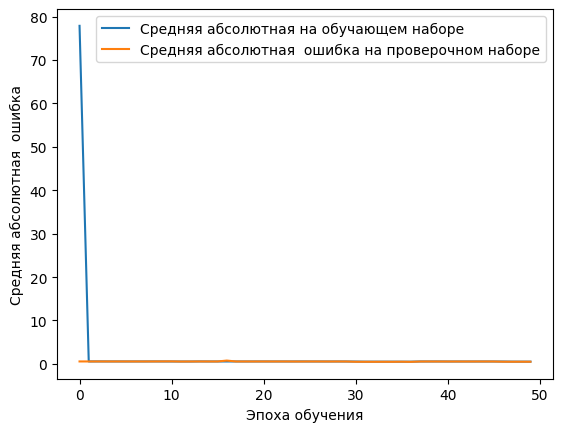

2192/2192 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step
Средняя абсолютная ошибка: 303009.40625 

Реальное значение: 996000.00  Предсказанное значение: 775015.00  Разница: 220985.00
Реальное значение: 140200.00  Предсказанное значение: 507035.88  Разница: 366835.88
Реальное значение: 750000.00  Предсказанное значение: 603373.75  Разница: 146626.25
Реальное значение: 970000.00  Предсказанное значение: 692743.06  Разница: 277256.94
Реальное значение: 205000.00  Предсказанное значение: 507035.88  Разница: 302035.88
Реальное значение: 985000.00  Предсказанное значение: 750829.19  Разница: 234170.81
Реальное значение: 589000.00  Предсказанное значение: 507035.88  Разница: 81964.12
Реальное значение: 500000.00  Предсказанное значение: 507035.88  Разница: 7035.88
Реальное значение: 1320000.00  Предсказанное значение: 586333.50  Разница: 733666.50
Реальное значение: 270000.00  Предсказанное значение: 507035.88  Разница: 237035.88


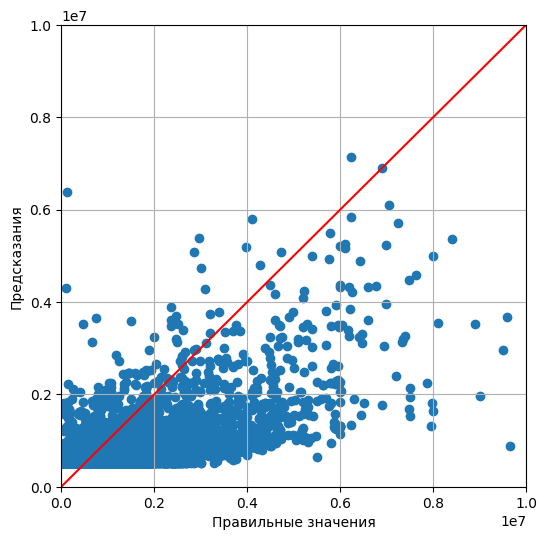

In [14]:
plot_history(history)
eval_net(model_final, [x_train_01, xBOW_model], y_train_exp, y_scaler=y_scaler)